dumbbell L = [-4.  0.  4.]  expected w*(-2, 0, 2) = [-4.  0.  4.]
dumbbell torque to keep omega constant = [ 0. -8.  0.]  expected (0, -2 w^2, 0) = (0, -8.0, 0)
random cloud: |L_direct - I omega| = 8.326672684688674e-16
eigenvalues of S: [0.00998497 0.08928544 0.36074916]  eigenvalues of I: [0.09927041 0.37073413 0.4500346 ]  trace(S) - eig(S): [0.09927041 0.37073413 0.4500346 ]
energy: 0.5 om^T I om = 0.2248783952178156   0.5 mass sum |om x r|^2 = 0.2248783952178157
rod S diag (sampled): [1.00014422e-04 9.99970801e-05 8.33728878e-02]  exact: R^2/4 = 0.0001  L^2/12 = 0.08333333333333333
rod I diag (sampled): [0.08347288 0.0834729  0.00020001]  exact: R^2/4+L^2/12 = 0.08343333333333333  R^2/2 = 0.0002
rod I off-diagonal max |.|: 1.2557425021117443e-06
theta    0 deg: n^T I n = 2.000115e-04, formula 2.000000e-04
theta   30 deg: n^T I n = 2.101714e-02, formula 2.100833e-02
theta   60 deg: n^T I n = 6.265358e-02, formula 6.262500e-02
theta   90 deg: n^T I n = 8.347288e-02, formula 8.343333

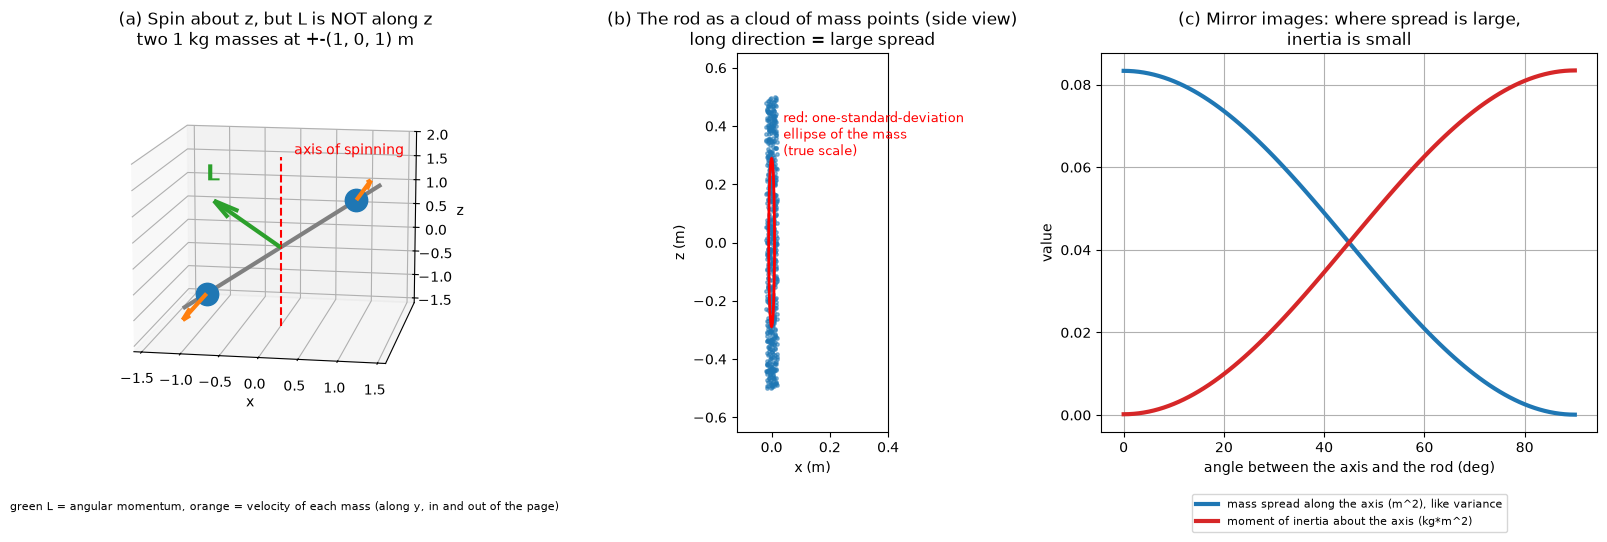

In [1]:
import os
import numpy as np  # type: ignore
import matplotlib.pyplot as plt  # type: ignore
from matplotlib.patches import Ellipse  # type: ignore
from datetime import datetime

RESULT_DIR = os.path.join(os.getcwd(), "result")
os.makedirs(RESULT_DIR, exist_ok=True)
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

# STEP 1: numeric checks of every formula used in the lesson
rng = np.random.default_rng(1)

# (a) tilted dumbbell: two 1 kg masses at +-(1, 0, 1) m, spinning about z at 2 1/s
m, w = 1.0, 2.0
r = np.array([[1.0, 0, 1.0], [-1.0, 0, -1.0]])
omega = np.array([0, 0, w])
L = sum(m * np.cross(ri, np.cross(omega, ri)) for ri in r)
print("dumbbell L =", L, " expected w*(-2, 0, 2) =", w * np.array([-2, 0, 2]))
torque = np.cross(omega, L)
print("dumbbell torque to keep omega constant =", torque, " expected (0, -2 w^2, 0) =", (0, -2 * w**2, 0))

# (b) random cloud: I from definition vs trace(S) 1 - S, and L = I omega
n = 200000
pts = rng.normal(size=(n, 3)) * np.array([0.3, 0.1, 0.6]) @ np.linalg.qr(rng.normal(size=(3, 3)))[0]
mass = 1.0 / n
S = mass * pts.T @ pts
I_def = mass * np.einsum("ni,ni->n", pts, pts).sum() * np.eye(3) - S
om = np.array([0.7, -1.2, 0.4])
L_direct = mass * np.cross(pts, np.cross(om, pts)).sum(axis=0)
print("random cloud: |L_direct - I omega| =", np.abs(L_direct - I_def @ om).max())
eS, eI = np.linalg.eigvalsh(S), np.linalg.eigvalsh(I_def)
print("eigenvalues of S:", eS, " eigenvalues of I:", eI, " trace(S) - eig(S):", np.sort(eS.sum() - eS))
print("energy: 0.5 om^T I om =", 0.5 * om @ I_def @ om, "  0.5 mass sum |om x r|^2 =", 0.5 * mass * (np.cross(om, pts) ** 2).sum())

# (c) our rod: solid cylinder, m = 1 kg, R = 0.02 m, L = 1 m, center of mass origin
M, R, Lr = 1.0, 0.02, 1.0
N = 3_000_000
rad = R * np.sqrt(rng.uniform(size=N)); ang = rng.uniform(0, 2 * np.pi, N)
P = np.column_stack([rad * np.cos(ang), rad * np.sin(ang), rng.uniform(-Lr / 2, Lr / 2, N)])
S_rod = M / N * P.T @ P
I_rod = np.trace(S_rod) * np.eye(3) - S_rod
print("rod S diag (sampled):", np.diag(S_rod), " exact: R^2/4 =", M * R**2 / 4, " L^2/12 =", M * Lr**2 / 12)
print("rod I diag (sampled):", np.diag(I_rod), " exact: R^2/4+L^2/12 =", M * (R**2 / 4 + Lr**2 / 12), " R^2/2 =", M * R**2 / 2)
print("rod I off-diagonal max |.|:", np.abs(I_rod - np.diag(np.diag(I_rod))).max())
# axis tilted by theta from the rod axis, in the x-z plane
th = np.deg2rad(np.array([0, 30, 60, 90]))
for t in th:
    nvec = np.array([np.sin(t), 0, np.cos(t)])
    print(f"theta {np.rad2deg(t):4.0f} deg: n^T I n = {nvec @ I_rod @ nvec:.6e}, formula {M*(R**2/4+Lr**2/12)*np.sin(t)**2 + M*R**2/2*np.cos(t)**2:.6e}")
# parallel axis, pivot at the end d = (0,0,0.5)
d = np.array([0, 0, 0.5])
I_piv = I_rod + M * (d @ d * np.eye(3) - np.outer(d, d))
print("I at pivot (end) diag:", np.diag(I_piv))

# STEP 2: figure
fig = plt.figure(figsize=(16, 5.6))
ax = fig.add_subplot(1, 3, 1, projection="3d")
ax.plot([-1.3, 1.3], [0, 0], [-1.3, 1.3], color="gray", linewidth=3)
ax.scatter(*r.T, s=260, color="C0", depthshade=False)
ax.plot([0, 0], [0, 0], [-1.6, 1.8], color="red", linestyle="--")
ax.text(0.9, 0, 1.9, "axis of spinning", color="red", ha="center")
ax.quiver(0, 0, 0, *(0.9 * L / np.linalg.norm(L) * 1.4), color="C2", linewidth=3)
ax.text(-0.9, 0, 1.3, "L", color="C2", ha="center", fontsize=16, fontweight="bold")
for ri in r:
    v = np.cross(omega, ri)
    ax.quiver(*ri, *(0.9 * v / np.linalg.norm(v)), color="C1", linewidth=3)
fig.text(0.17, 0.08, "green L = angular momentum, orange = velocity of each mass (along y, in and out of the page)", color="black", ha="center", fontsize=8)
ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1, 1); ax.set_zlim(-1.6, 2.0)
ax.view_init(elev=12, azim=-80)
ax.set_xlabel("x"); ax.set_zlabel("z"); ax.set_yticks([])
ax.set_title("(a) Spin about z, but L is NOT along z\ntwo 1 kg masses at +-(1, 0, 1) m")

ax = fig.add_subplot(1, 3, 2)
cr = 0.02 * np.sqrt(rng.uniform(size=600)); ca = rng.uniform(0, 2 * np.pi, 600); cloud = np.column_stack([cr * np.cos(ca), rng.uniform(-0.5, 0.5, 600)])
ax.scatter(cloud[:, 0], cloud[:, 1], s=6, color="C0", alpha=0.5)
sx, sz = np.sqrt(R**2 / 4), np.sqrt(Lr**2 / 12)
ax.add_patch(Ellipse((0, 0), 2 * sx, 2 * sz, fill=False, color="red", linewidth=2))
ax.text(0.04, 0.3, "red: one-standard-deviation\nellipse of the mass\n(true scale)", color="red", fontsize=9)
ax.set_xlim(-0.12, 0.4); ax.set_ylim(-0.65, 0.65); ax.set_aspect("equal")
ax.set_title("(b) The rod as a cloud of mass points (side view)\nlong direction = large spread")
ax.set_xlabel("x (m)"); ax.set_ylabel("z (m)")

ax = fig.add_subplot(1, 3, 3)
thd = np.linspace(0, 90, 91); t = np.deg2rad(thd)
spread = (Lr**2 / 12) * np.cos(t) ** 2 + (R**2 / 4) * np.sin(t) ** 2
inertia = M * (R**2 / 4 + Lr**2 / 12) * np.sin(t) ** 2 + M * R**2 / 2 * np.cos(t) ** 2
ax.plot(thd, spread, color="C0", linewidth=3, label="mass spread along the axis (m^2), like variance")
ax.plot(thd, inertia, color="C3", linewidth=3, label="moment of inertia about the axis (kg*m^2)")
ax.set_xlabel("angle between the axis and the rod (deg)"); ax.set_ylabel("value")
ax.set_title("(c) Mirror images: where spread is large,\ninertia is small")
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.15)); ax.grid(True)
fig.tight_layout()
fig.savefig(os.path.join(RESULT_DIR, f"inertia_tensor_lesson_{TIMESTAMP}.png"), dpi=110)
print("saved")